This notebook aims to debug my current ccsa custom implementation and check wheter my adaptation can make it more parameter-independent. We will first focus on diminishing the potential differences with the NLOPT implementation, then provide possible alternatives for the adaptation of parameters like the trust region, the curvature, w, parameter for the control of the curvature update. Finally we will understand how stochasticity affects this and how we can change the acceptance criterion to be suitable for stochastic optimization.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import nlopt
import torch

## Unconstrained Stochastic Convex Optimization:

Let's try the stochastic optimization problem
$$
\min_{x \in \mathbb{R}^n} E[f(x,\xi)]
$$
where
$$
f(x,\xi) = \Vert A(x + \xi) \Vert_2^2
$$
and $A = A^T$ is an $n \times n$ real-symmetric matrix, while $\xi \in \mathbb{R}^n$

The expectation value $E[\cdots]$ is for $\xi$ drawn from i.i.d. Gaussian random variables $\xi_k \sim N(0,\sigma^2)$.

Analytically, the minimizer should simply be at $x = 0$ while the minimum is $ \sigma^2 \mathrm{tr}(A^2)$.

Note that $\nabla_x f = 2A(x + \xi)$.

Our starting guess will simply be `x = randn(n)`, and we'll use $A = I$ to start with.

[8.013279499463652]


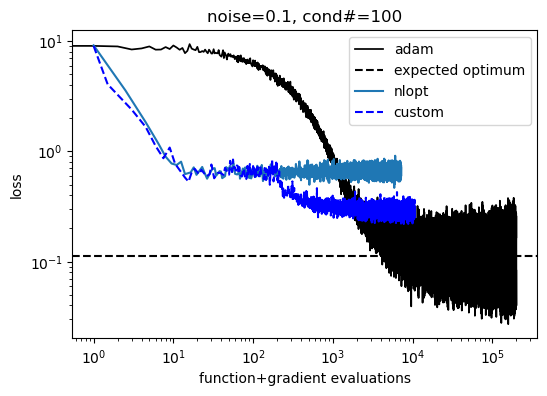

In [2]:
from experiments.unconstrained_convex import stoch_convex_unc_exp
from ccsa.optimizer import CCSAOptimizer
from ccsa.params import MMA_SigmaParams, MMA_RhoParams
import nlopt

# deterministic RNG for the experiment
n = 100
seed = 42
sigma_min = 1e-8
rng = np.random.RandomState(seed)
x_init = rng.randn(n)

# Initialize Customer Optimizer
rho_params = MMA_RhoParams(softening=0.5, min_growth=1.01, max_multiplier=10.0, decay=1.0)
sigma_params = MMA_SigmaParams(expand=1.2, contract=0.7, sigma_min=sigma_min,  rel_min=0.01, rel_max=10.0)

optimizer = CCSAOptimizer(
            params=[torch.tensor(x_init, dtype=torch.float32, requires_grad=False)],
            fun=None,   
            g=None,
            x0 = x_init,
            bounds=None,
            rho_init=1.0,
            max_inner=5,
            rho_params=rho_params,
            sigma_params=sigma_params,
            df=None,      
            dg=None
        )

# Initialize Nlopt Optimizer
opt = nlopt.opt(nlopt.LD_MMA, n)
opt.set_param("sigma_min", sigma_min)
opt.set_param("inner_maxeval", 5)


# Run experiments for the new implementation
for noise in [0.1]:
    for cond in [100]:
        stoch_convex_unc_exp(optimizer, opt, noise=noise, cond=cond, outer = 5000, rng=rng, x_init=x_init)




## CONVEX STOCHASTIC OBJECTIVE DETERMINISTIC LINEAR CONSTRAINT

Let's define our first constrained optimization algorithm. We will start with a simple case in which we just take the above and modify with a simple linear constraint. 

$$
\min_{x \in \mathbb{R}^n} \; \mathbb{E}[f(x,\xi)] \quad \quad s.t. \quad c^T x - b \leq 0
$$

where  

$$
f(x,\xi) = \Vert A(x + \xi) \Vert_2^2, 
$$  

and $A = A^T$ is an $n \times n$ real-symmetric matrix, while $\xi \in \mathbb{R}^n$ is a random vector with $\mathbb{E}[\xi]=0$ and $\mathrm{Cov}(\xi) = \sigma_\xi^2 I$. We will divide it into 2 cases:

1.  Active Constraint (i.e. unconstrained solution is NOT in the feasible region). In this case the solution lies on the feasibility boundary and can be analytically computed by forming the lagrangian starting from the expected valued function (ignoring for the moment the noise related term)

$$
\mathcal{L}(x,\lambda) = x^T A^2 x + \lambda (c^T x - b).
$$

The KKT condition gives us

$$
\nabla_x \mathcal{L} = 2 A^2 x + \lambda c = 0 
\quad \Longrightarrow \quad 
x = -\frac{\lambda}{2} (A^2)^{-1} c.
$$

Impose the constraint \(c^T x = b\):

$$
c^T \Big(-\frac{\lambda}{2} (A^2)^{-1} c \Big) = b
\quad \Longrightarrow \quad
\lambda = -\frac{2b}{c^T (A^2)^{-1} c}.
$$

Hence the constrained optimizer is

$$
x^\ast_{\text{constr}} 
= \frac{b}{c^T (A^2)^{-1} c} \, (A^2)^{-1} c.
$$


To obtain the optimum we plug into the objective:

$$
F(x^\ast_{\text{constr}})
= (x^\ast_{\text{constr}})^T A^2 x^\ast_{\text{constr}} 
+ \sigma_\xi^2 \, \mathrm{tr}(A^2).
$$

The quadratic term evaluates to

$$
(x^\ast_{\text{constr}})^T A^2 x^\ast_{\text{constr}}
= \frac{b^2}{c^T (A^2)^{-1} c}.
$$

and the final optimal value is

$$
F^\ast_{\text{constr}} 
= \frac{b^2}{c^T (A^2)^{-1} c} 
+ \sigma_\xi^2 \, \mathrm{tr}(A^2).
$$



2. Inactive Constraint (i.e. unconstrained solution is in the feasible region). In this case, similarly as before, the expected optimum is $\sigma^2 \mathrm{tr}(A^2) $.  

---

As a baseline we implement the augmented lagrangian version of Adam, which is a state-of-the-art method for constrained stochastic optimization.  

The augmented Lagrangian for our problem is defined as  

$$
\mathcal{L}_\rho(x, \lambda) = \mathbb{E}[f(x,\xi)] + \lambda \, (c^\top x - d) + \tfrac{\rho}{2} \, (c^\top x - d)^2,
$$  

where $\lambda \ge 0$ is the Lagrange multiplier and $\rho > 0$ is a penalty parameter.  

At each iteration $k$ we should perform a stochastic Adam update on the primal variable $x$ using $g_k$, a stochastic estimate of the gradient of the augmented Lagrangian,  

$$
g_k = \nabla f(x_k, \xi_k) + (\lambda_k + \rho \, g(x_k)) c,
$$  

with constraint function $g(x) = c^\top x - d$.  

The dual variable is updated at each step according to  

$$
\lambda_{k+1} = \max \big( 0, \lambda_k + \rho \, g(x_{k+1}) \big).
$$  

This results in a single-loop primal-dual method where the primal variable is updated using Adam with stochastic gradients, and the dual variable is updated via a projected gradient descent step to enforce feasibility.


/var/folders/v2/87rr3r9j7hg956gtw351l0pw0000gq/T/ipykernel_61378/4035364743.py:69: UserWarning: max_inner > 1 has no effect when conservative=False: the inner loop always exits after one iteration.
  ccsa_opt = CCSAOptimizer(


=== Running noise = 0.1, cond# = 100 ===
Analytic expected optimum:
  active? True
  ||x*||=10.8753, λ*=0.0160915
  E[f(x*)]=0.152784 (noise const=0.112555)
Unconstrained optimum: E[f(x_uncon)]= 0.112555, g(x_uncon)=5
Initial constraint g(x0)=-8.95779 (init_feasible=True)

AL-Adam finished:
  last f_est=0.16315, g(x)=0.100229, λ=0.100229

nlopt σ=0.1: res=5, ||x||=15.2, g(x)=-3.99
AL-Adam finished:
  last f_est=0.16315, g(x)=0.100229, λ=0.100229

nlopt σ=0.1: res=5, ||x||=15.2, g(x)=-3.99
CCSA σ=0.1: cumulative_wval=46.5505, weighted_evals=300.0, x_history_len=201
CCSA σ=0.1: cumulative_wval=46.5505, weighted_evals=300.0, x_history_len=201
CSSCA (tau_obj=0.4, tau_cons=0.4, rho=1.0): last f=58.539, last g[0]=-61.0911
CSSCA (tau_obj=0.4, tau_cons=0.4, rho=1.0): last f=58.539, last g[0]=-61.0911
CSSCA (tau_obj=1.0, tau_cons=1.0, rho=1.0): last f=0.17003, last g[0]=-0.0880678
CSSCA (tau_obj=1.0, tau_cons=1.0, rho=1.0): last f=0.17003, last g[0]=-0.0880678
CSSCA (tau_obj=10.0, tau_cons=10.0

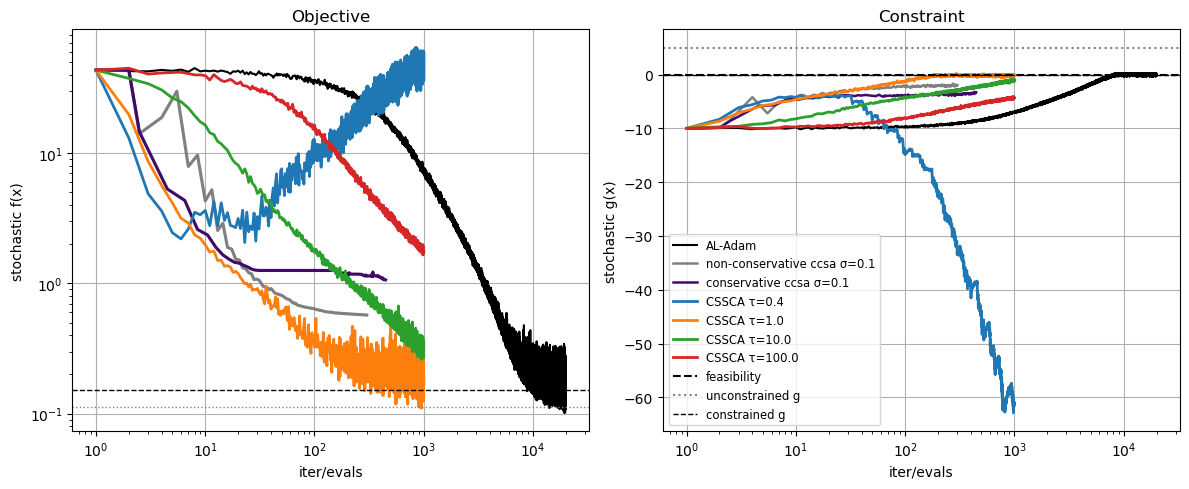

In [3]:
import numpy as np
import torch 
from ccsa.params import MMA_SigmaParams, MMA_RhoParams
from ccsa.optimizer import CCSAOptimizer
import nlopt

import os, random

from experiments.constrained_convex import stoch_convex_con_exp

# deterministic RNG for the experiment
n = 100

seed = 2

active_constraint = True  
init_feasible = True

np.random.seed(seed)

random.seed(seed)

rng = np.random.RandomState(seed)

torch.manual_seed(seed)
torch.use_deterministic_algorithms(True)  # if using torch ops (may raise on non-deterministic ops)
# OpenMP / BLAS threading (see #3)
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"


# init point (local version using rng)
def init_point_local(n: int, c: np.ndarray, b: float, force_feasible: bool = False) -> np.ndarray:
    x0 = rng.randn(n)
    g0 = float(np.dot(c, x0) - b)
    if force_feasible:
        if g0 > 0:
            delta = ((b - np.dot(c, x0)) - 10.0) * c / (np.dot(c, c))
            x0 = x0 + delta
    else:
        if g0 <= 0:
            delta = ((b - np.dot(c, x0)) + 10.0) * c / (np.dot(c, c))
            x0 = x0 + delta
    return x0

# random linear constraint
c = rng.randn(n)
c /= np.linalg.norm(c)
x_uncon = np.zeros(n)
if active_constraint is None:
    b = rng.uniform(-1, 1)
elif active_constraint:
    b = np.dot(c, x_uncon) - 5.0
else:
    b = np.dot(c, x_uncon) + 5.0

x0 = init_point_local(n, c, b, force_feasible=init_feasible)

sigma_min = 1e-6
n = 100
rho_params = MMA_RhoParams(softening=0.5, min_growth=1.01, max_multiplier=10.0, decay=0.1)
sigma_params_run = MMA_SigmaParams(expand=1.2, contract=0.7, sigma_min=sigma_min, rel_min=0.01, rel_max=10.0)



ccsa_opt = CCSAOptimizer(
            params=x0.copy(),    # initial point
            fun=None,                # single-call oracle (value+grad from same xi)
            g=None,
            rho_params=rho_params,
            sigma_params=sigma_params_run,
            bounds=None,
            rho_init=1.0,
            max_inner=5,
            df=None,   # let MMAOptimizer request grad via fun(..., grad=True)
            x0=x0.copy(),
            use_quadratic_surrogates=True,
            conservative=False

        )

ccsa_quad = CCSAOptimizer(
            params=x0.copy(),    # initial point
            fun=None,                # single-call oracle (value+grad from same xi)
            g=None,
            rho_params=rho_params,
            sigma_params=sigma_params_run,
            bounds=None,
            rho_init=1.0,
            max_inner=5,
            df=None,   # let MMAOptimizer request grad via fun(..., grad=True)
            x0=x0.copy(),
            use_quadratic_surrogates=True              
        )


opt = nlopt.opt(nlopt.LD_MMA, n)
opt.set_param("sigma_min", sigma_min)
opt.set_param("inner_maxeval", 5)


# Run experiments for the new implementation
for noise in [0.1]:
    for cond in [100]:
        print(f"=== Running noise = {noise}, cond# = {cond} ===")
        stoch_convex_con_exp(ccsa_opt, ccsa_quad, opt, c=c, b=b, x0=x0, noise=noise, cond=cond, seed=seed, sigma_mins=[1e-1], maxiters_adam = 20000,
    mma_maxeval = 200,
    active_constraint = True,
    init_feasible =True,
    cssca_tau_obj=[0.4, 1.0, 10.0, 100.0], cssca_tau_cons=[0.4, 1.0, 10.0, 100.0]) #0.03, 0.1, 1.0, 10.0

=== Running noise = 0.01, cond# = 1 ===
Analytic expected optimum:
  active? True
  ||x*||=5, λ*=10
  E[f(x*)]=25.01 (noise const=0.01)
Unconstrained optimum: E[f(x_uncon)]= 0.01, g(x_uncon)=5
Initial constraint g(x0)=-0.895779 (init_feasible=True)

AL-Adam finished:
  last f_est=25.1094, g(x)=0.0200173, λ=10.0016

nlopt σ=0.1: res=5, ||x||=5.01, g(x)=0.00569
AL-Adam finished:
  last f_est=25.1094, g(x)=0.0200173, λ=10.0016

nlopt σ=0.1: res=5, ||x||=5.01, g(x)=0.00569
CCSA σ=0.1: cumulative_wval=168.566, weighted_evals=483.0, x_history_len=201
CCSA σ=0.1: cumulative_wval=168.566, weighted_evals=483.0, x_history_len=201
CSSCA (tau_obj=0.5, tau_cons=0.5, rho=1.0): last f=24.9813, last g[0]=0.00309584
CSSCA (tau_obj=0.5, tau_cons=0.5, rho=1.0): last f=24.9813, last g[0]=0.00309584
CSSCA (tau_obj=10.0, tau_cons=10.0, rho=1.0): last f=25.041, last g[0]=0.0117591
CSSCA (tau_obj=10.0, tau_cons=10.0, rho=1.0): last f=25.041, last g[0]=0.0117591
CSSCA (tau_obj=100.0, tau_cons=100.0, rho=1.0): 

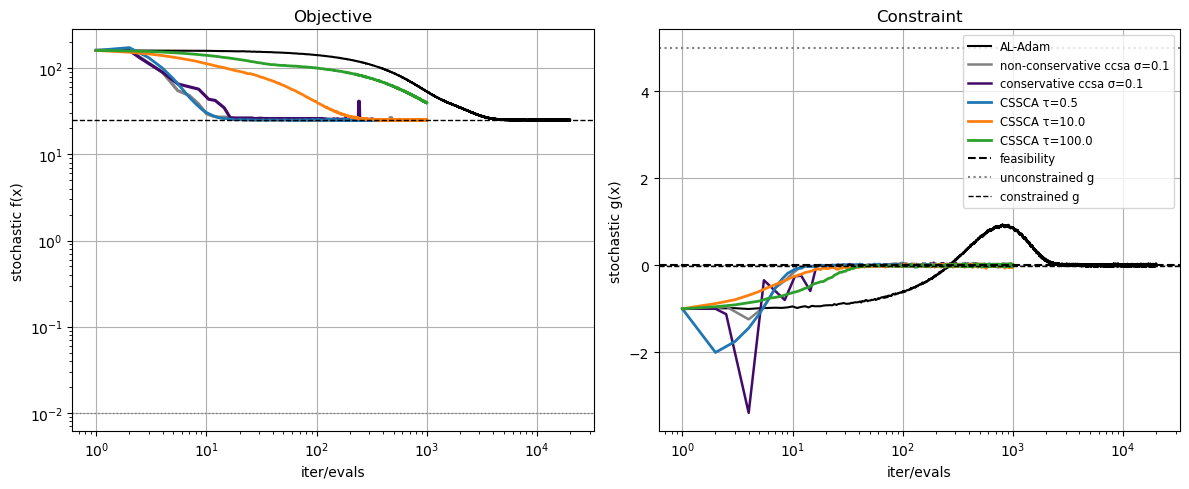

In [4]:
import numpy as np
import torch 
from ccsa.params import MMA_SigmaParams, MMA_RhoParams
from ccsa.optimizer import CCSAOptimizer
import nlopt

import os, random

from experiments.constrained_convex import stoch_convex_con_exp
seed = 2

active_constraint = True  
init_feasible = True

np.random.seed(seed)

random.seed(seed)

rng = np.random.RandomState(seed)

torch.manual_seed(seed)
torch.use_deterministic_algorithms(True)  # if using torch ops (may raise on non-deterministic ops)
# OpenMP / BLAS threading (see #3)
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"


# init point (local version using rng)
def init_point_local(n: int, c: np.ndarray, b: float, force_feasible: bool = False) -> np.ndarray:
    x0 = rng.randn(n)
    g0 = float(np.dot(c, x0) - b)
    if force_feasible:
        if g0 > 0:
            delta = ((b - np.dot(c, x0)) - 1.0) * c / (np.dot(c, c))
            x0 = x0 + delta
    else:
        if g0 <= 0:
            delta = ((b - np.dot(c, x0)) + 1.0) * c / (np.dot(c, c))
            x0 = x0 + delta
    return x0

# random linear constraint
c = rng.randn(n)
c /= np.linalg.norm(c)
x_uncon = np.zeros(n)
if active_constraint is None:
    b = rng.uniform(-1, 1)
elif active_constraint:
    b = np.dot(c, x_uncon) - 5.0
else:
    b = np.dot(c, x_uncon) + 5.0

x0 = init_point_local(n, c, b, force_feasible=init_feasible)

sigma_min = 1e-6
n = 100
rho_params = MMA_RhoParams(softening=0.5, min_growth=1.01, max_multiplier=10.0, decay=0.1)
sigma_params_run = MMA_SigmaParams(expand=1.2, contract=0.7, sigma_min=sigma_min, rel_min=0.01, rel_max=10.0)



ccsa_opt = CCSAOptimizer(
            params=x0.copy(),    # initial point
            fun=None,                # single-call oracle (value+grad from same xi)
            g=None,
            rho_params=rho_params,
            sigma_params=sigma_params_run,
            bounds=None,
            rho_init=1.0,
            max_inner=5,
            df=None,   # let MMAOptimizer request grad via fun(..., grad=True)
            x0=x0.copy()               
        )

ccsa_quad = CCSAOptimizer(
            params=x0.copy(),    # initial point
            fun=None,                # single-call oracle (value+grad from same xi)
            g=None,
            rho_params=rho_params,
            sigma_params=sigma_params_run,
            bounds=None,
            rho_init=1.0,
            max_inner=5,
            df=None,   # let MMAOptimizer request grad via fun(..., grad=True)
            x0=x0.copy(),
            use_quadratic_surrogates=True              
        )


opt = nlopt.opt(nlopt.LD_MMA, n)
opt.set_param("sigma_min", sigma_min)
opt.set_param("inner_maxeval", 5)


# Run experiments for the new implementation
for noise in [0.01]:
    for cond in [1]:
        print(f"=== Running noise = {noise}, cond# = {cond} ===")
        stoch_convex_con_exp(ccsa_opt, ccsa_quad, opt, c=c, b=b, x0=x0, noise=noise, cond=cond, seed=seed, sigma_mins=[1e-1], maxiters_adam = 20000,
    mma_maxeval = 200,
    active_constraint = True,
    init_feasible =True,
    cssca_tau_obj=[0.5, 10.0, 100.0], cssca_tau_cons=[0.5, 10.0, 100.0])

/var/folders/v2/87rr3r9j7hg956gtw351l0pw0000gq/T/ipykernel_61378/2686484911.py:61: UserWarning: max_inner > 1 has no effect when conservative=False: the inner loop always exits after one iteration.
  ccsa_opt = CCSAOptimizer(


Using diagonal exponential-quadratic objective n=100, noise=0.1, m in [0.001,1]
Linear constraint: ||c||=1, b=-5
Analytic expected optimum (on expectation):
  active? True
  ||x*||=8.19161, λ*=0.0441552
  E[f(x*)]=1.29615
Unconstrained baseline: E[f(0)]= 1.16069, g(0)=5
Initial constraint g(x0)=-1.00104 (init_feasible=True)

AL-Adam finished:
  last f_est=13.4948, g(x)=-0.234545, λ=0

nlopt σ=0.001: res=5, ||x||=10, g(x)=-1.24
AL-Adam finished:
  last f_est=13.4948, g(x)=-0.234545, λ=0

nlopt σ=0.001: res=5, ||x||=10, g(x)=-1.24


/Users/antoniovaragnolo/Desktop/Research/CCSA/experiments/convex_constrained2.py:161: RuntimeWarning: overflow encountered in exp
  val = float(np.exp(quad))


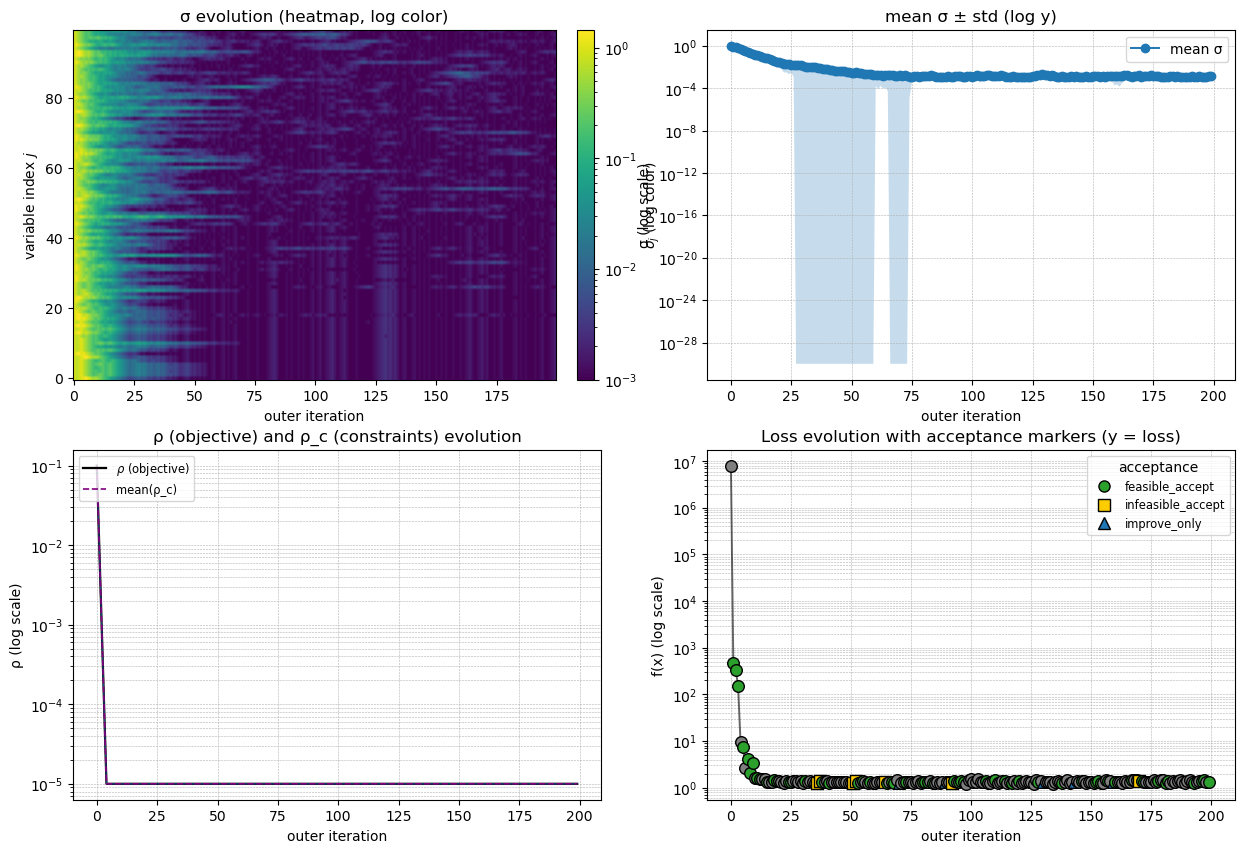

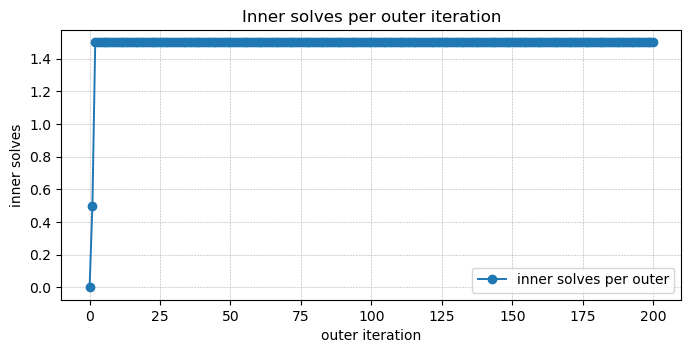


=== MMA Diagnostic Summary ===
Recorded outer iterations (f history): 201
Sigma: final mean = 1.496e-03, final std = 3.456e-04
Rho (objective): final = 1.000e-05
Rho_c (constraints): shape = (200, 1), final mean = 1.000e-05

Acceptance counts:
Counter({'feasibility_min': 133, 'feasible_accept': 55, 'infeasible_accept': 7, 'improve_only': 5})

Average inner solves per outer step (observed): 1.49
CCSA σ=0.001: cumulative_wval=82.0075, weighted_evals=300.0, x_history_len=201
CSSCA (tau_obj=1.0, tau_cons=1.0, rho=1.0): last f=1.21013e+20, last g[0]=-14.8425
CSSCA (tau_obj=1.0, tau_cons=1.0, rho=1.0): last f=1.21013e+20, last g[0]=-14.8425
CSSCA (tau_obj=10.0, tau_cons=10.0, rho=1.0): last f=3.95393e+18, last g[0]=-14.2191
CSSCA (tau_obj=10.0, tau_cons=10.0, rho=1.0): last f=3.95393e+18, last g[0]=-14.2191
CSSCA (tau_obj=100.0, tau_cons=100.0, rho=1.0): last f=1.48344, last g[0]=-0.170391
CCSA σ=0.001: cumulative_wval=0.635765, weighted_evals=465.0, x_history_len=201
CSSCA (tau_obj=100.0, 

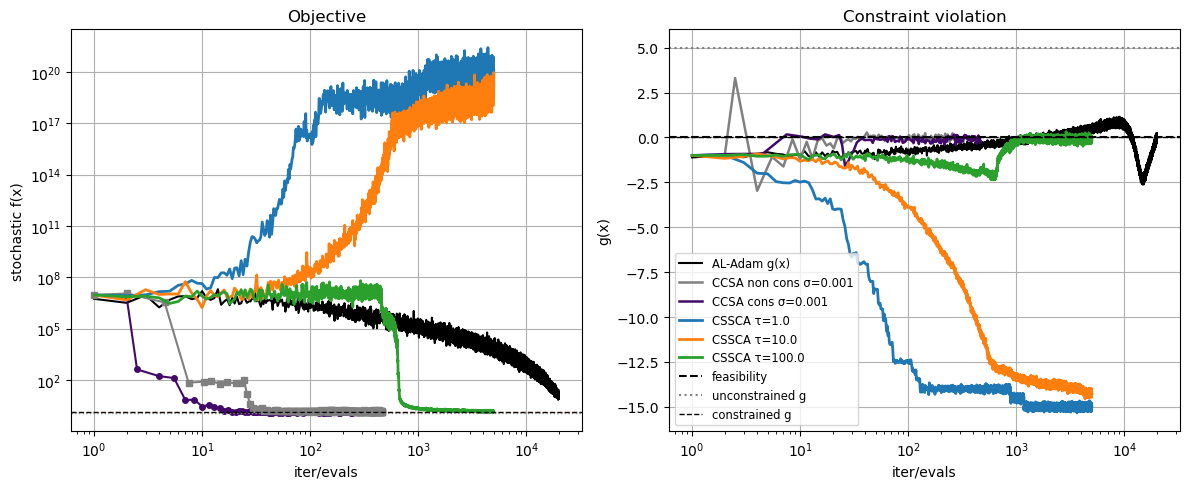

Returned x_star norm: 8.191609825087385
Returned expected value at x_star: 1.2961520038932766


In [5]:
# run_expquad.py
import numpy as np
import torch
import nlopt
import os, random
from ccsa.params import MMA_SigmaParams, MMA_RhoParams
from ccsa.optimizer import CCSAOptimizer
from experiments.convex_constrained2 import stoch_expquad_diag_exp

# reproducibility
seed = 1
np.random.seed(seed)
random.seed(seed)
torch.manual_seed(seed)
torch.use_deterministic_algorithms(True)

os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

# problem params
n = 100
active_constraint = True
init_feasible = True
rng = np.random.RandomState(seed)

# init x0 helper
def init_point_local(n: int, c: np.ndarray, b: float, force_feasible: bool = False) -> np.ndarray:
    x0 = rng.randn(n)
    g0 = float(np.dot(c, x0) - b)
    if force_feasible:
        if g0 > 0:
            delta = ((b - np.dot(c, x0)) - 1.0) * c / (np.dot(c, c))
            x0 = x0 + delta
    else:
        if g0 <= 0:
            delta = ((b - np.dot(c, x0)) + 1.0) * c / (np.dot(c, c))
            x0 = x0 + delta
    return x0

# random linear constraint
c = rng.randn(n)
c /= np.linalg.norm(c)
x_uncon = np.zeros(n)
if active_constraint is None:
    b = rng.uniform(-1, 1)
elif active_constraint:
    b = np.dot(c, x_uncon) - 5.0
else:
    b = np.dot(c, x_uncon) + 5.0

x0 = init_point_local(n, c, b, force_feasible=init_feasible)

# optimizer settings
sigma_min = 1e-3
rho_params = MMA_RhoParams(softening=0.5, min_growth=1.01, max_multiplier=10.0, decay=0.1)
sigma_params_run = MMA_SigmaParams(expand=1.2, contract=0.7, sigma_min=sigma_min, rel_min=0.01, rel_max=10.0)

ccsa_opt = CCSAOptimizer(
    params=x0.copy(),
    fun=None,
    g=None,
    rho_params=rho_params,
    sigma_params=sigma_params_run,
    bounds=None,
    rho_init=1.0,
    max_inner=5,
    df=None,
    x0=x0.copy(),
    use_quadratic_surrogates=True,
    conservative=False
)



ccsa_quad = CCSAOptimizer(
    params=x0.copy(),
    fun=None,
    g=None,
    rho_params=rho_params,
    sigma_params=sigma_params_run,
    bounds=None,
    rho_init=1.0,
    max_inner=5,
    df=None,
    x0=x0.copy(),
    use_quadratic_surrogates=True
)

opt = nlopt.opt(nlopt.LD_MMA, n)
opt.set_param("sigma_min", sigma_min)
opt.set_param("inner_maxeval", 5)

# run the experiment
results = stoch_expquad_diag_exp(
    optimizer=ccsa_opt,#
    optimizer_quad=ccsa_quad,
    optimizer_nlopt=opt,
    ccsa_names=['CCSA non cons', 'CCSA cons'],
    noise=0.1,
    cond=1,
    c=c, b=b, x0=x0,
    sigma_mins=[sigma_min],
    seed=seed,
    maxiters_adam=20000,
    mma_maxeval=200,
    active_constraint=active_constraint,
    init_feasible=init_feasible,
    cssca_tau_obj=[1.0, 10.0, 100.0], 
    cssca_tau_cons=[1.0, 10.0, 100.0],
    cssca_samples_per_iter=1,
    curv_change='large'
)

print("Returned x_star norm:", np.linalg.norm(results["x_star"]))
print("Returned expected value at x_star:", results["val_star"])

/var/folders/v2/87rr3r9j7hg956gtw351l0pw0000gq/T/ipykernel_6303/4246253059.py:96: UserWarning:

max_inner > 1 has no effect when conservative=False: the inner loop always exits after one iteration.



Rotation angle θ = 6.0760
Constraint ||c||=1.0000, b=-0.5000
Objective noise σ_f=0.01, Constraint noise σ_g=0.05
CSSCA τo=0.1, τc=0.1, final f=-0.0010
CSSCA τo=0.1, τc=0.1, final f=-0.0010
CSSCA τo=1.0, τc=1.0, final f=-0.8752
CSSCA τo=1.0, τc=1.0, final f=-0.8752
CSSCA τo=10, τc=10, final f=-0.0782
CSSCA τo=10, τc=10, final f=-0.0782
CSSCA τo=100.0, τc=100.0, final f=-0.0463
CSSCA τo=100.0, τc=100.0, final f=-0.0463


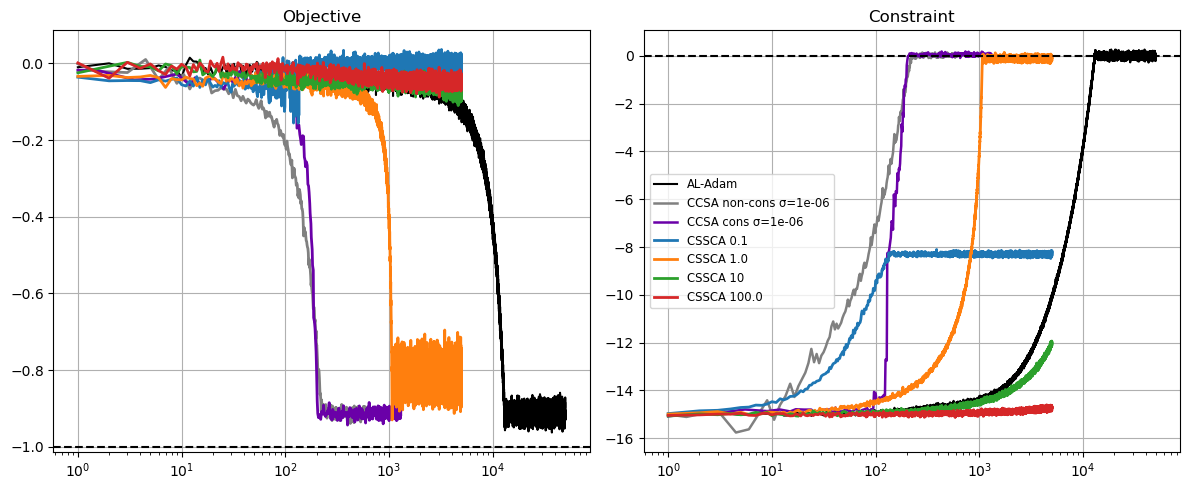

{'x_al': array([0.48210094, 0.31290027]),
 'hist_al': {'iter': [1,
   2,
   3,
   4,
   5,
   6,
   7,
   8,
   9,
   10,
   11,
   12,
   13,
   14,
   15,
   16,
   17,
   18,
   19,
   20,
   21,
   22,
   23,
   24,
   25,
   26,
   27,
   28,
   29,
   30,
   31,
   32,
   33,
   34,
   35,
   36,
   37,
   38,
   39,
   40,
   41,
   42,
   43,
   44,
   45,
   46,
   47,
   48,
   49,
   50,
   51,
   52,
   53,
   54,
   55,
   56,
   57,
   58,
   59,
   60,
   61,
   62,
   63,
   64,
   65,
   66,
   67,
   68,
   69,
   70,
   71,
   72,
   73,
   74,
   75,
   76,
   77,
   78,
   79,
   80,
   81,
   82,
   83,
   84,
   85,
   86,
   87,
   88,
   89,
   90,
   91,
   92,
   93,
   94,
   95,
   96,
   97,
   98,
   99,
   100,
   101,
   102,
   103,
   104,
   105,
   106,
   107,
   108,
   109,
   110,
   111,
   112,
   113,
   114,
   115,
   116,
   117,
   118,
   119,
   120,
   121,
   122,
   123,
   124,
   125,
   126,
   127,
   128,
   129,
   130,
   131,

In [ ]:
import numpy as np
import torch
import nlopt
import os, random

from ccsa.params import MMA_SigmaParams, MMA_RhoParams
from ccsa.optimizer import CCSAOptimizer

from experiments.constrained_convex3 import rotated_exp_stoch_constrained_exp


# ============================================================
# Deterministic setup
# ============================================================
seed = 2
np.random.seed(seed)
random.seed(seed)
torch.manual_seed(seed)
torch.use_deterministic_algorithms(True)

os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

rng = np.random.RandomState(seed)

# ============================================================
# Problem dimension (NOW 2D)
# ============================================================
n = 2


# ============================================================
# Linear constraint
# ============================================================
c = rng.randn(n)
c /= np.linalg.norm(c)

x_uncon = np.zeros(n)

active_constraint = True
init_feasible = True

if active_constraint:
    b = np.dot(c, x_uncon) - 0.5
else:
    b = np.dot(c, x_uncon) + 0.5


def init_point_local(n, c, b, force_feasible=False, margin=15.0):
    x0 = rng.randn(n)
    g0 = float(np.dot(c, x0) - b)

    # c normalized or not: we divide by c^T c so it's fine
    cc = np.dot(c, c)

    if force_feasible:
        if g0 > 0:
            # push *inside* the feasible half-space by an extra margin
            delta = (b - np.dot(c, x0) - margin) * c / cc
            x0 = x0 + delta
    else:
        if g0 <= 0:
            # push *outside* the feasible half-space by an extra margin
            delta = (b - np.dot(c, x0) + margin) * c / cc
            x0 = x0 + delta

    return x0


x0 = init_point_local(n, c, b, force_feasible=init_feasible)


# ============================================================
# CCSA Optimizers (unchanged structure)
# ============================================================
sigma_min = 1e-3

rho_params = MMA_RhoParams(
    softening=0.5,
    min_growth=1.01,
    max_multiplier=10.0,
    decay=0.1
)

sigma_params_run = MMA_SigmaParams(
    expand=1.2,
    contract=0.7,
    sigma_min=sigma_min,
    rel_min=0.01,
    rel_max=10.0
)

ccsa_opt = CCSAOptimizer(
    params=x0.copy(),
    fun=None,
    g=None,
    rho_params=rho_params,
    sigma_params=sigma_params_run,
    bounds=None,
    rho_init=1.0,
    max_inner=5,
    df=None,
    x0=x0.copy(),
    use_quadratic_surrogates=True,
    conservative=False
)

ccsa_quad = CCSAOptimizer(
    params=x0.copy(),
    fun=None,
    g=None,
    rho_params=rho_params,
    sigma_params=sigma_params_run,
    bounds=None,
    rho_init=1.0,
    max_inner=5,
    df=None,
    x0=x0.copy(),
    use_quadratic_surrogates=True
)



rotated_exp_stoch_constrained_exp(
    ccsa_opt,
    ccsa_quad,
    ccsa_names=['CCSA non-cons', 'CCSA cons'],
    a=100,
    tau=1,
    noise_std=0.01,
    c=c,
    b=b,
    x0=x0,
    seed=seed+2,
    sigma_mins=[1e-6],
    maxiters_adam=50000,
    mma_maxeval=400,
    cssca_tau_obj=[0.1, 1.0, 10, 100.0],
    cssca_tau_cons=[0.1, 1.0, 10, 100.0],
)


# Test Different Updates

/var/folders/v2/87rr3r9j7hg956gtw351l0pw0000gq/T/ipykernel_87936/2283669719.py:61: UserWarning:

max_inner > 1 has no effect when conservative=False: the inner loop always exits after one iteration.

/var/folders/v2/87rr3r9j7hg956gtw351l0pw0000gq/T/ipykernel_87936/2283669719.py:79: UserWarning:

max_inner > 1 has no effect when conservative=False: the inner loop always exits after one iteration.



Using diagonal exponential-quadratic objective n=100, noise=0.1, m in [0.001,1]
Linear constraint: ||c||=1, b=-5
Analytic expected optimum (on expectation):
  active? True
  ||x*||=8.19161, λ*=0.0441552
  E[f(x*)]=1.29615
Unconstrained baseline: E[f(0)]= 1.16069, g(0)=5
Initial constraint g(x0)=-1.00104 (init_feasible=True)

AL-Adam finished:
  last f_est=13.4948, g(x)=-0.234545, λ=0

nlopt σ=0.001: res=5, ||x||=10, g(x)=-1.32
AL-Adam finished:
  last f_est=13.4948, g(x)=-0.234545, λ=0

nlopt σ=0.001: res=5, ||x||=10, g(x)=-1.32


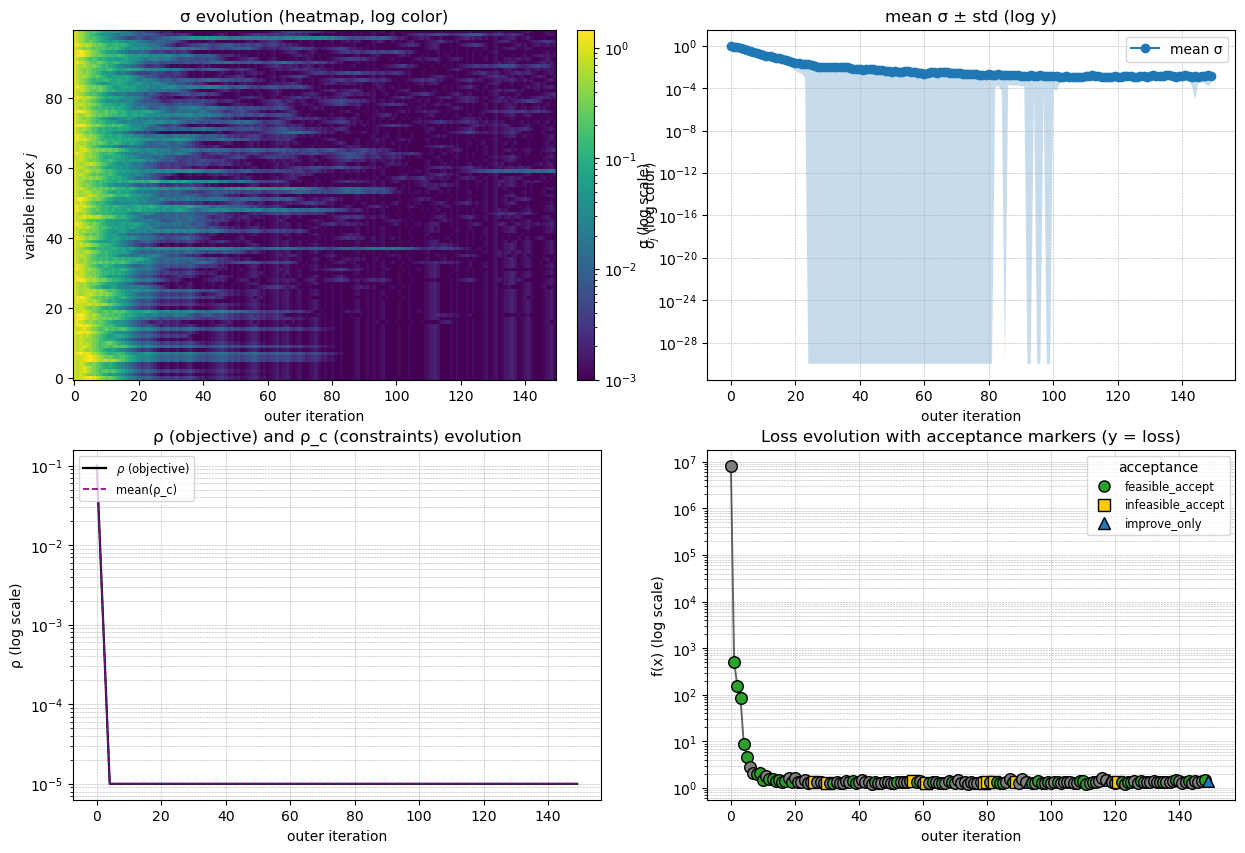

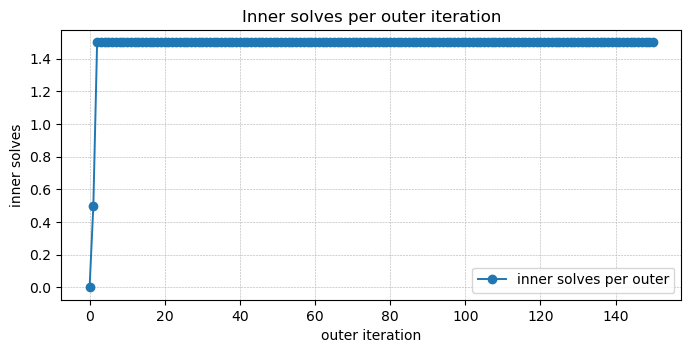


=== MMA Diagnostic Summary ===
Recorded outer iterations (f history): 151
Sigma: final mean = 1.313e-03, final std = 1.023e-03
Rho (objective): final = 1.000e-05
Rho_c (constraints): shape = (150, 1), final mean = 1.000e-05

Acceptance counts:
Counter({'feasibility_min': 93, 'feasible_accept': 45, 'infeasible_accept': 9, 'improve_only': 3})

Average inner solves per outer step (observed): 1.48
CCSA σ=0.001: cumulative_wval=61.9587, weighted_evals=225.0, x_history_len=151
CSSCA (tau_obj=100.0, tau_cons=100.0, rho=1.0): last f=1.44953, last g[0]=-0.0957896
CSSCA (tau_obj=100.0, tau_cons=100.0, rho=1.0): last f=1.44953, last g[0]=-0.0957896
CCSA σ=0.001: cumulative_wval=5.08941, weighted_evals=225.0, x_history_len=151
CCSA σ=0.001: cumulative_wval=5.08941, weighted_evals=225.0, x_history_len=151


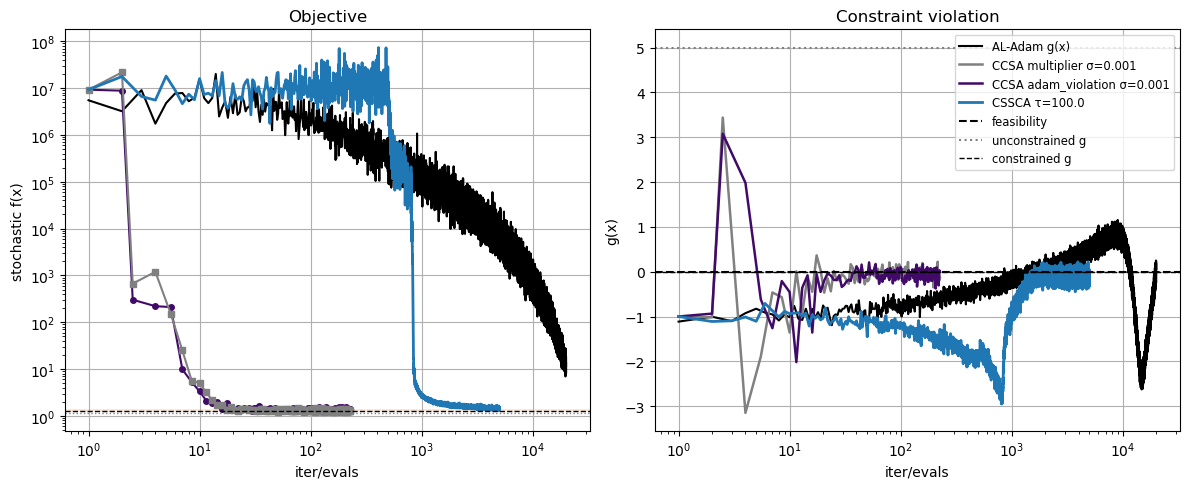

Returned x_star norm: 8.191609825087385
Returned expected value at x_star: 1.2961520038932766


In [6]:
# run_expquad.py
import numpy as np
import torch
import nlopt
import os, random
from ccsa.params import MMA_SigmaParams, MMA_RhoParams
from ccsa.optimizer import CCSAOptimizer
from experiments.convex_constrained2 import stoch_expquad_diag_exp

# reproducibility
seed = 1
np.random.seed(seed)
random.seed(seed)
torch.manual_seed(seed)
torch.use_deterministic_algorithms(True)

os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

# problem params
n = 100
active_constraint = True
init_feasible = True
rng = np.random.RandomState(seed)

# init x0 helper
def init_point_local(n: int, c: np.ndarray, b: float, force_feasible: bool = False) -> np.ndarray:
    x0 = rng.randn(n)
    g0 = float(np.dot(c, x0) - b)
    if force_feasible:
        if g0 > 0:
            delta = ((b - np.dot(c, x0)) - 1.0) * c / (np.dot(c, c))
            x0 = x0 + delta
    else:
        if g0 <= 0:
            delta = ((b - np.dot(c, x0)) + 1.0) * c / (np.dot(c, c))
            x0 = x0 + delta
    return x0

# random linear constraint
c = rng.randn(n)
c /= np.linalg.norm(c)
x_uncon = np.zeros(n)
if active_constraint is None:
    b = rng.uniform(-1, 1)
elif active_constraint:
    b = np.dot(c, x_uncon) - 5.0
else:
    b = np.dot(c, x_uncon) + 5.0

x0 = init_point_local(n, c, b, force_feasible=init_feasible)

# optimizer settings
sigma_min = 1e-3
rho_params = MMA_RhoParams(softening=0.5, min_growth=1.01, max_multiplier=10.0, decay=0.1)
sigma_params_run = MMA_SigmaParams(expand=1.2, contract=0.7, sigma_min=sigma_min, rel_min=0.01, rel_max=10.0)

ccsa_opt = CCSAOptimizer(
    params=x0.copy(),
    fun=None,
    g=None,
    rho_params=rho_params,
    sigma_params=sigma_params_run,
    bounds=None,
    rho_init=1.0,
    max_inner=5,
    df=None,
    x0=x0.copy(),
    use_quadratic_surrogates=True,
    conservative=False,
    #per_coord_rho=False
)



ccsa_quad = CCSAOptimizer(
    params=x0.copy(),
    fun=None,
    g=None,
    rho_params=rho_params,
    sigma_params=sigma_params_run,
    bounds=None,
    rho_init=1.0,
    max_inner=5,
    df=None,
    x0=x0.copy(),
    use_quadratic_surrogates=True,
    update_rule="adam_violation",
    conservative=False,
    #per_coord_rho=False,
    update_rule_kwargs={'lr': 1e-2, 'beta1': 0.05, 'beta2': 0.05, 'eps': 1e-8,
                'min_curv': 1e-6, 'max_curv': 1e-2}
)

opt = nlopt.opt(nlopt.LD_MMA, n)
opt.set_param("sigma_min", sigma_min)
opt.set_param("inner_maxeval", 5)

# run the experiment
results = stoch_expquad_diag_exp(
    optimizer=ccsa_opt,#
    optimizer_quad=ccsa_quad,
    optimizer_nlopt=opt,
    ccsa_names=['CCSA multiplier', 'CCSA adam_violation'],
    noise=0.1,
    cond=1,
    c=c, b=b, x0=x0,
    sigma_mins=[sigma_min],
    seed=seed,
    maxiters_adam=20000,
    mma_maxeval=150,
    active_constraint=active_constraint,
    init_feasible=init_feasible,
    cssca_tau_obj=[100.0], 
    cssca_tau_cons=[100.0],
    cssca_samples_per_iter=1,
    curv_change='large'
)

print("Returned x_star norm:", np.linalg.norm(results["x_star"]))
print("Returned expected value at x_star:", results["val_star"])

Rotation angle θ = 6.0760
Constraint ||c||=1.0000, b=-0.5000
Objective noise σ_f=0.01, Constraint noise σ_g=0.05
CSSCA τo=0.1, τc=0.1, final f=-0.0042
CSSCA τo=0.1, τc=0.1, final f=-0.0042
CSSCA τo=1.0, τc=1.0, final f=-0.8494
CSSCA τo=1.0, τc=1.0, final f=-0.8494
CSSCA τo=10, τc=10, final f=-0.0842
CSSCA τo=10, τc=10, final f=-0.0842
CSSCA τo=100.0, τc=100.0, final f=-0.0412
CSSCA τo=100.0, τc=100.0, final f=-0.0412


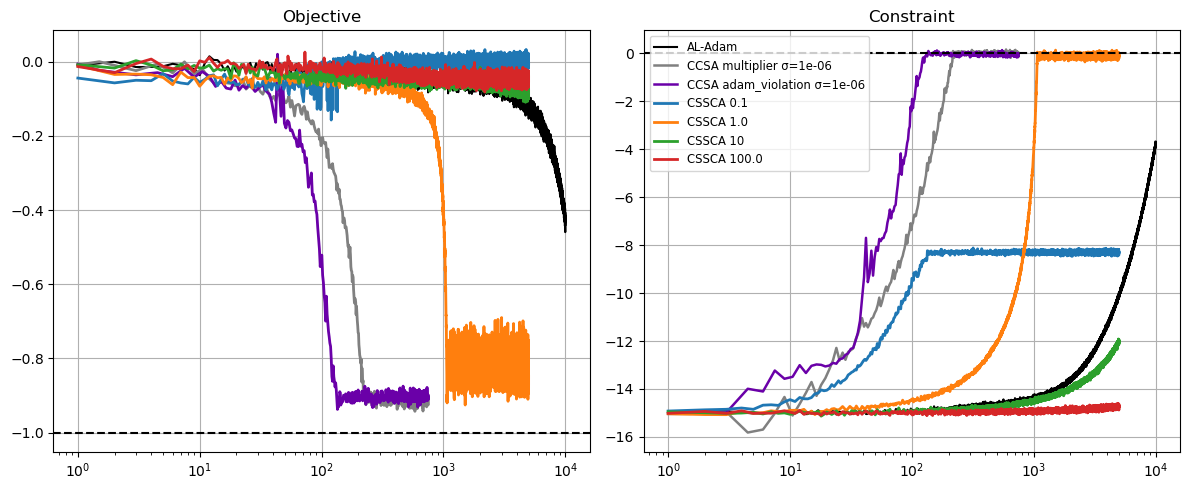

{'x_al': array([4.11406502, 1.52456148]),
 'hist_al': {'iter': [1,
   2,
   3,
   4,
   5,
   6,
   7,
   8,
   9,
   10,
   11,
   12,
   13,
   14,
   15,
   16,
   17,
   18,
   19,
   20,
   21,
   22,
   23,
   24,
   25,
   26,
   27,
   28,
   29,
   30,
   31,
   32,
   33,
   34,
   35,
   36,
   37,
   38,
   39,
   40,
   41,
   42,
   43,
   44,
   45,
   46,
   47,
   48,
   49,
   50,
   51,
   52,
   53,
   54,
   55,
   56,
   57,
   58,
   59,
   60,
   61,
   62,
   63,
   64,
   65,
   66,
   67,
   68,
   69,
   70,
   71,
   72,
   73,
   74,
   75,
   76,
   77,
   78,
   79,
   80,
   81,
   82,
   83,
   84,
   85,
   86,
   87,
   88,
   89,
   90,
   91,
   92,
   93,
   94,
   95,
   96,
   97,
   98,
   99,
   100,
   101,
   102,
   103,
   104,
   105,
   106,
   107,
   108,
   109,
   110,
   111,
   112,
   113,
   114,
   115,
   116,
   117,
   118,
   119,
   120,
   121,
   122,
   123,
   124,
   125,
   126,
   127,
   128,
   129,
   130,
   131,

In [7]:
import numpy as np
import torch
import nlopt
import os, random

from ccsa.params import MMA_SigmaParams, MMA_RhoParams
from ccsa.optimizer import CCSAOptimizer

from experiments.constrained_convex3 import rotated_exp_stoch_constrained_exp


# ============================================================
# Deterministic setup
# ============================================================
seed = 2
np.random.seed(seed)
random.seed(seed)
torch.manual_seed(seed)
torch.use_deterministic_algorithms(True)

os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

rng = np.random.RandomState(seed)

# ============================================================
# Problem dimension (NOW 2D)
# ============================================================
n = 2


# ============================================================
# Linear constraint
# ============================================================
c = rng.randn(n)
c /= np.linalg.norm(c)

x_uncon = np.zeros(n)

active_constraint = True
init_feasible = True

if active_constraint:
    b = np.dot(c, x_uncon) - 0.5
else:
    b = np.dot(c, x_uncon) + 0.5


def init_point_local(n, c, b, force_feasible=False, margin=15.0):
    x0 = rng.randn(n)
    g0 = float(np.dot(c, x0) - b)

    # c normalized or not: we divide by c^T c so it's fine
    cc = np.dot(c, c)

    if force_feasible:
        if g0 > 0:
            # push *inside* the feasible half-space by an extra margin
            delta = (b - np.dot(c, x0) - margin) * c / cc
            x0 = x0 + delta
    else:
        if g0 <= 0:
            # push *outside* the feasible half-space by an extra margin
            delta = (b - np.dot(c, x0) + margin) * c / cc
            x0 = x0 + delta

    return x0


x0 = init_point_local(n, c, b, force_feasible=init_feasible)


# ============================================================
# CCSA Optimizers (unchanged structure)
# ============================================================
sigma_min = 1e-6

rho_params = MMA_RhoParams(
    softening=0.5,
    min_growth=1.01,
    max_multiplier=10.0,
    decay=0.1
)

sigma_params_run = MMA_SigmaParams(
    expand=1.2,
    contract=0.7,
    sigma_min=sigma_min,
    rel_min=0.01,
    rel_max=10.0
)

ccsa_opt = CCSAOptimizer( # gray
    params=x0.copy(),
    fun=None,
    g=None,
    rho_params=rho_params,
    sigma_params=sigma_params_run,
    bounds=None,
    rho_init=1.0,
    max_inner=1,
    df=None,
    x0=x0.copy(),
    use_quadratic_surrogates=True,
    conservative=False,
    #per_coord_rho=False,
    update_rule='multiplier'
)

ccsa_quad = CCSAOptimizer( # purple
    params=x0.copy(),
    fun=None,
    g=None,
    rho_params=rho_params,
    sigma_params=sigma_params_run,
    bounds=None,
    rho_init=1.0,
    max_inner=1,
    df=None,
    x0=x0.copy(),
    use_quadratic_surrogates=True,
    conservative=False,
    #per_coord_rho=False,
    update_rule='adam_violation',
    update_rule_kwargs={'lr': 5e-3, 'beta1': 0.01, 'beta2': 0.01, 'eps': 1e-8,
 'min_curv': 1e-6, 'max_curv': 1e-2}
)



rotated_exp_stoch_constrained_exp(
    ccsa_opt,
    ccsa_quad,
    ccsa_names=["CCSA multiplier", "CCSA adam_violation"],
    a=100,
    tau=1,
    noise_std=0.01,
    c=c,
    b=b,
    x0=x0,
    seed=seed+2,
    sigma_mins=[1e-6],
    maxiters_adam=10000,
    mma_maxeval=500,
    cssca_tau_obj=[0.1, 1.0, 10, 100.0],
    cssca_tau_cons=[0.1, 1.0, 10, 100.0],

)


# PER COORD UPDATES RHO

/var/folders/v2/87rr3r9j7hg956gtw351l0pw0000gq/T/ipykernel_87936/2183264926.py:61: UserWarning:

max_inner > 1 has no effect when conservative=False: the inner loop always exits after one iteration.

/var/folders/v2/87rr3r9j7hg956gtw351l0pw0000gq/T/ipykernel_87936/2183264926.py:79: UserWarning:

max_inner > 1 has no effect when conservative=False: the inner loop always exits after one iteration.



Using diagonal exponential-quadratic objective n=100, noise=0.1, m in [0.001,1]
Linear constraint: ||c||=1, b=-5
Analytic expected optimum (on expectation):
  active? True
  ||x*||=8.19161, λ*=0.0441552
  E[f(x*)]=1.29615
Unconstrained baseline: E[f(0)]= 1.16069, g(0)=5
Initial constraint g(x0)=-1.00104 (init_feasible=True)

AL-Adam finished:
  last f_est=13.4948, g(x)=-0.234545, λ=0

nlopt σ=1e-06: res=5, ||x||=10, g(x)=-1.24
AL-Adam finished:
  last f_est=13.4948, g(x)=-0.234545, λ=0

nlopt σ=1e-06: res=5, ||x||=10, g(x)=-1.24


/Users/antoniovaragnolo/Desktop/Research/CCSA/experiments/convex_constrained2.py:163: RuntimeWarning:

overflow encountered in multiply



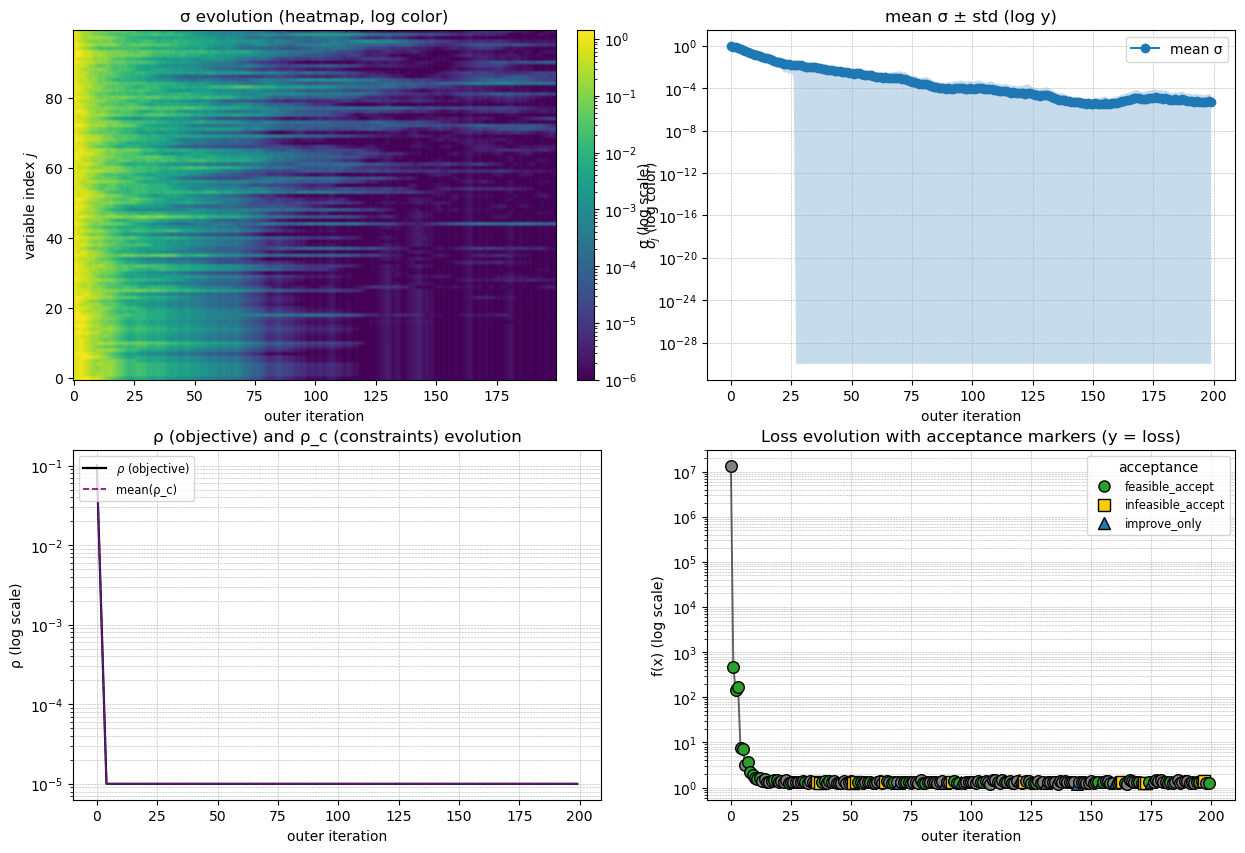

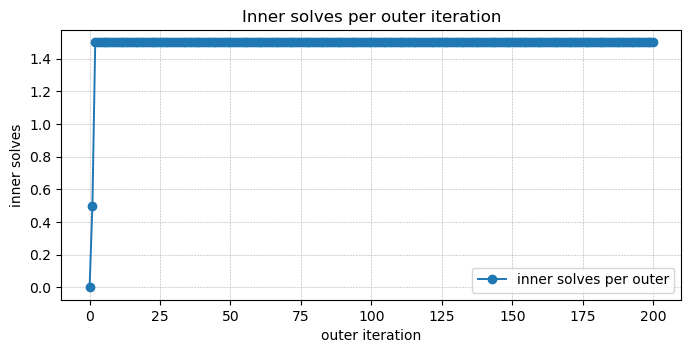


=== MMA Diagnostic Summary ===
Recorded outer iterations (f history): 201
Sigma: final mean = 5.586e-06, final std = 1.916e-05
Rho (objective): final = 1.000e-05
Rho_c (constraints): shape = (200, 1), final mean = 1.000e-05

Acceptance counts:
Counter({'feasibility_min': 128, 'feasible_accept': 52, 'infeasible_accept': 11, 'improve_only': 9})

Average inner solves per outer step (observed): 1.49
CCSA σ=1e-06: cumulative_wval=33.9162, weighted_evals=300.0, x_history_len=201
CSSCA (tau_obj=1000.0, tau_cons=1000.0, rho=1.0): last f=4.55273, last g[0]=-0.906406
CSSCA (tau_obj=1000.0, tau_cons=1000.0, rho=1.0): last f=4.55273, last g[0]=-0.906406
CCSA σ=1e-06: cumulative_wval=45.9207, weighted_evals=300.0, x_history_len=201
CCSA σ=1e-06: cumulative_wval=45.9207, weighted_evals=300.0, x_history_len=201


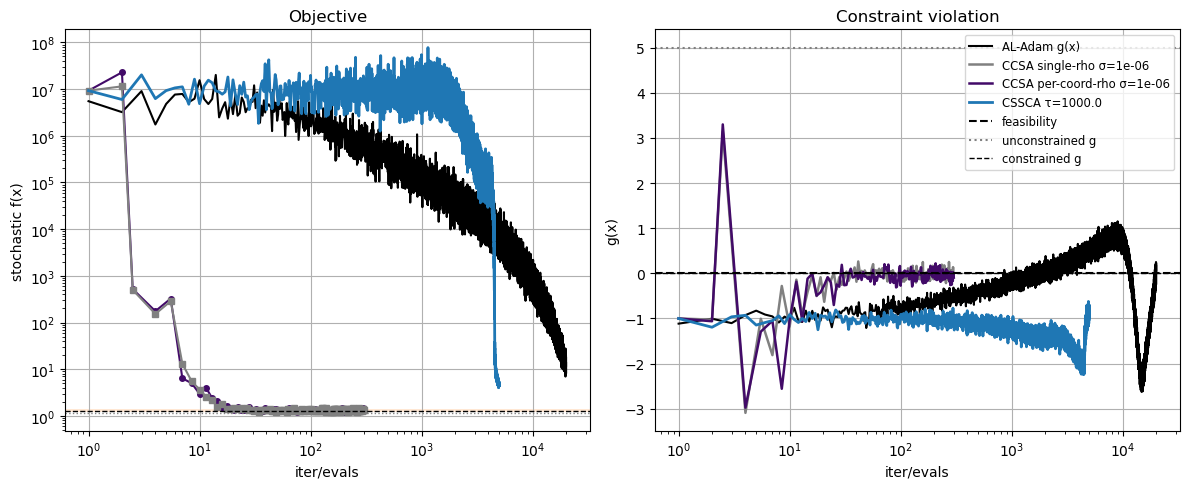

Returned x_star norm: 8.191609825087385
Returned expected value at x_star: 1.2961520038932766


In [8]:
# run_expquad.py
import numpy as np
import torch
import nlopt
import os, random
from ccsa.params import MMA_SigmaParams, MMA_RhoParams
from ccsa.optimizer import CCSAOptimizer
from experiments.convex_constrained2 import stoch_expquad_diag_exp

# reproducibility
seed = 1
np.random.seed(seed)
random.seed(seed)
torch.manual_seed(seed)
torch.use_deterministic_algorithms(True)

os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

# problem params
n = 100
active_constraint = True
init_feasible = True
rng = np.random.RandomState(seed)

# init x0 helper
def init_point_local(n: int, c: np.ndarray, b: float, force_feasible: bool = False) -> np.ndarray:
    x0 = rng.randn(n)
    g0 = float(np.dot(c, x0) - b)
    if force_feasible:
        if g0 > 0:
            delta = ((b - np.dot(c, x0)) - 1.0) * c / (np.dot(c, c))
            x0 = x0 + delta
    else:
        if g0 <= 0:
            delta = ((b - np.dot(c, x0)) + 1.0) * c / (np.dot(c, c))
            x0 = x0 + delta
    return x0

# random linear constraint
c = rng.randn(n)
c /= np.linalg.norm(c)
x_uncon = np.zeros(n)
if active_constraint is None:
    b = rng.uniform(-1, 1)
elif active_constraint:
    b = np.dot(c, x_uncon) - 5.0
else:
    b = np.dot(c, x_uncon) + 5.0

x0 = init_point_local(n, c, b, force_feasible=init_feasible)

# optimizer settings
sigma_min = 1e-6
rho_params = MMA_RhoParams(softening=0.5, min_growth=1.01, max_multiplier=10.0, decay=0.1)
sigma_params_run = MMA_SigmaParams(expand=1.2, contract=0.7, sigma_min=sigma_min, rel_min=0.01, rel_max=10.0)

ccsa_opt = CCSAOptimizer(
    params=x0.copy(),
    fun=None,
    g=None,
    rho_params=rho_params,
    sigma_params=sigma_params_run,
    bounds=None,
    rho_init=1.0,
    max_inner=5,
    df=None,
    x0=x0.copy(),
    use_quadratic_surrogates=True,
    conservative=False,
    per_coord_rho=True
)



ccsa_quad = CCSAOptimizer(
    params=x0.copy(),
    fun=None,
    g=None,
    rho_params=rho_params,
    sigma_params=sigma_params_run,
    bounds=None,
    rho_init=1.0,
    max_inner=5,
    df=None,
    x0=x0.copy(),
    use_quadratic_surrogates=True,
    #update_rule="adam_violation",
    conservative=False,
    per_coord_rho=False,
    #update_rule_kwargs={'lr': 1e-2, 'beta1': 0.05, 'beta2': 0.05, 'eps': 1e-8,
    #            'min_curv': sigma_min, 'max_curv': 1e3}
)

opt = nlopt.opt(nlopt.LD_MMA, n)
opt.set_param("sigma_min", sigma_min)
opt.set_param("inner_maxeval", 5)

# run the experiment
results = stoch_expquad_diag_exp(
    optimizer=ccsa_opt,#
    optimizer_quad=ccsa_quad,
    optimizer_nlopt=opt,
    ccsa_names=['CCSA single-rho', 'CCSA per-coord-rho'],
    noise=0.1,
    cond=1,
    c=c, b=b, x0=x0,
    sigma_mins=[sigma_min],
    seed=seed,
    maxiters_adam=20000,
    mma_maxeval=200,
    active_constraint=active_constraint,
    init_feasible=init_feasible,
    cssca_tau_obj=[1000.0], 
    cssca_tau_cons=[1000.0],
    cssca_samples_per_iter=1,
    curv_change='large'
)

print("Returned x_star norm:", np.linalg.norm(results["x_star"]))
print("Returned expected value at x_star:", results["val_star"])

Rotation angle θ = 6.0760
Constraint ||c||=1.0000, b=-0.5000
Objective noise σ_f=0.01, Constraint noise σ_g=0.05
CSSCA τo=0.1, τc=0.1, final f=0.0092
CSSCA τo=0.1, τc=0.1, final f=0.0092
CSSCA τo=1.0, τc=1.0, final f=-0.7852
CSSCA τo=1.0, τc=1.0, final f=-0.7852
CSSCA τo=10, τc=10, final f=-0.0930
CSSCA τo=10, τc=10, final f=-0.0930
CSSCA τo=100.0, τc=100.0, final f=-0.0387
CSSCA τo=100.0, τc=100.0, final f=-0.0387


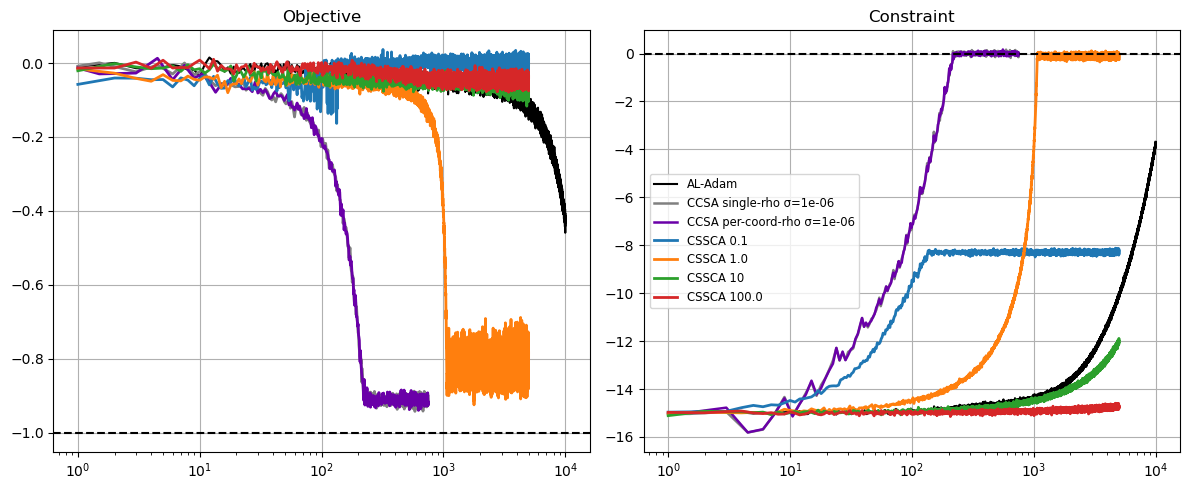

{'x_al': array([4.11406502, 1.52456148]),
 'hist_al': {'iter': [1,
   2,
   3,
   4,
   5,
   6,
   7,
   8,
   9,
   10,
   11,
   12,
   13,
   14,
   15,
   16,
   17,
   18,
   19,
   20,
   21,
   22,
   23,
   24,
   25,
   26,
   27,
   28,
   29,
   30,
   31,
   32,
   33,
   34,
   35,
   36,
   37,
   38,
   39,
   40,
   41,
   42,
   43,
   44,
   45,
   46,
   47,
   48,
   49,
   50,
   51,
   52,
   53,
   54,
   55,
   56,
   57,
   58,
   59,
   60,
   61,
   62,
   63,
   64,
   65,
   66,
   67,
   68,
   69,
   70,
   71,
   72,
   73,
   74,
   75,
   76,
   77,
   78,
   79,
   80,
   81,
   82,
   83,
   84,
   85,
   86,
   87,
   88,
   89,
   90,
   91,
   92,
   93,
   94,
   95,
   96,
   97,
   98,
   99,
   100,
   101,
   102,
   103,
   104,
   105,
   106,
   107,
   108,
   109,
   110,
   111,
   112,
   113,
   114,
   115,
   116,
   117,
   118,
   119,
   120,
   121,
   122,
   123,
   124,
   125,
   126,
   127,
   128,
   129,
   130,
   131,

In [9]:
import numpy as np
import torch
import nlopt
import os, random

from ccsa.params import MMA_SigmaParams, MMA_RhoParams
from ccsa.optimizer import CCSAOptimizer

from experiments.constrained_convex3 import rotated_exp_stoch_constrained_exp


# ============================================================
# Deterministic setup
# ============================================================
seed = 2
np.random.seed(seed)
random.seed(seed)
torch.manual_seed(seed)
torch.use_deterministic_algorithms(True)

os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

rng = np.random.RandomState(seed)

# ============================================================
# Problem dimension (NOW 2D)
# ============================================================
n = 2


# ============================================================
# Linear constraint
# ============================================================
c = rng.randn(n)
c /= np.linalg.norm(c)

x_uncon = np.zeros(n)

active_constraint = True
init_feasible = True

if active_constraint:
    b = np.dot(c, x_uncon) - 0.5
else:
    b = np.dot(c, x_uncon) + 0.5


def init_point_local(n, c, b, force_feasible=False, margin=15.0):
    x0 = rng.randn(n)
    g0 = float(np.dot(c, x0) - b)

    # c normalized or not: we divide by c^T c so it's fine
    cc = np.dot(c, c)

    if force_feasible:
        if g0 > 0:
            # push *inside* the feasible half-space by an extra margin
            delta = (b - np.dot(c, x0) - margin) * c / cc
            x0 = x0 + delta
    else:
        if g0 <= 0:
            # push *outside* the feasible half-space by an extra margin
            delta = (b - np.dot(c, x0) + margin) * c / cc
            x0 = x0 + delta

    return x0


x0 = init_point_local(n, c, b, force_feasible=init_feasible)


# ============================================================
# CCSA Optimizers (unchanged structure)
# ============================================================
sigma_min = 1e-6

rho_params = MMA_RhoParams(
    softening=0.5,
    min_growth=1.01,
    max_multiplier=10.0,
    decay=0.1
)

sigma_params_run = MMA_SigmaParams(
    expand=1.2,
    contract=0.7,
    sigma_min=sigma_min,
    rel_min=0.01,
    rel_max=10.0
)

ccsa_opt = CCSAOptimizer( # gray
    params=x0.copy(),
    fun=None,
    g=None,
    rho_params=rho_params,
    sigma_params=sigma_params_run,
    bounds=None,
    rho_init=1.0,
    max_inner=1,
    df=None,
    x0=x0.copy(),
    use_quadratic_surrogates=True,
    conservative=False,
    per_coord_rho=False,
    #update_rule='multiplier'
)

ccsa_quad = CCSAOptimizer( # purple
    params=x0.copy(),
    fun=None,
    g=None,
    rho_params=rho_params,
    sigma_params=sigma_params_run,
    bounds=None,
    rho_init=1.0,
    max_inner=1,
    df=None,
    x0=x0.copy(),
    use_quadratic_surrogates=True,
    conservative=False,
    per_coord_rho=True,
    #update_rule='adam_violation',
    #update_rule_kwargs={'lr': 1e-2, 'beta1': 0.05, 'beta2': 0.05, 'eps': 1e-8,
    #            'min_curv': sigma_min, 'max_curv': 1e3}
)



rotated_exp_stoch_constrained_exp(
    ccsa_opt,
    ccsa_quad,
    ccsa_names=["CCSA single-rho", "CCSA per-coord-rho"],
    a=100,
    tau=1,
    noise_std=0.01,
    c=c,
    b=b,
    x0=x0,
    seed=seed+2,
    sigma_mins=[1e-6],
    maxiters_adam=10000,
    mma_maxeval=500,
    cssca_tau_obj=[0.1, 1.0, 10, 100.0],
    cssca_tau_cons=[0.1, 1.0, 10, 100.0],

)
